# Imports

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from transformers import AutoModelForCausalLM , AutoTokenizer
from huggingface_hub import login
from google.colab import userdata
import pandas as pd
import torch
from tqdm.auto import tqdm
import json
import matplotlib.pyplot as plt
import numpy as np
import shutil
import math
import re
device = "cuda"
torch_dtype = None
base_model_id = "Qwen/Qwen2.5-1.5B-Instruct"

In [3]:
login(token=userdata.get('HF_TOKEN'))

In [4]:
df_testing = pd.read_json("/content/drive/MyDrive/opinion-mining/test_labeled_v2.json")
df_testing.head()

,input,prediction
0,"Boot time is super fast, around anywhere from ...","{""domain"":""electronics"",""aspects"":[{""term"":""Bo..."
1,tech support would not fix the problem unless ...,"{""domain"":""software"",""aspects"":[{""term"":""tech ..."
2,but in resume this computer rocks!,"{""domain"":""electronics"",""aspects"":[{""term"":""co..."
3,Set up was easy.,"{""domain"":""general"",""aspects"":[{""term"":""Set up..."
4,Did not enjoy the new Windows 8 and touchscree...,"{""domain"":""software"",""aspects"":[{""term"":""Windo..."


# Loading Base Model

In [5]:
model = AutoModelForCausalLM.from_pretrained(
    base_model_id,
    device_map="auto",
    torch_dtype = torch_dtype
)

tokenizer = AutoTokenizer.from_pretrained(base_model_id)

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

# Base Model Responses

In [6]:
def run_qwen(prompt):
    messages = [
        {"role": "user", "content": prompt}
    ]

    inputs = tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt"
    ).to(model.device)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=65,
            do_sample=False,
            temperature = 0.0,
            top_k = None,
            top_p = None
        )

    result = tokenizer.decode(
        output[0][inputs["input_ids"].shape[-1]:],
        skip_special_tokens=True
    )

    return result.strip()

In [7]:
results = []

for i, row in tqdm(df_testing.iterrows(), total=len(df_testing), desc="Running Qwen inference"):
    text = row['input']

    prompt = "\n".join(["You extract structured information from text and return only valid JSON.",
                            "",
                            "No explanation No introduction No conclusion",
                            "Extract the domain and all aspect terms with their sentiment polarity.",
                                  "- Domains: electronics, restaurants, movies, books, software, general",
                                  "- Polarity: positive, negative, neutral",
                                  "- Extract ALL aspects mentioned in the text",
                                  "input :",
                                  text,
                                  "output format:",
                                  '{"domain":"...","aspects":[{"term":"...","polarity":"..."}, ...]}'
                        ])

    prediction = run_qwen(prompt)

    results.append({
        "input": text,
        "prediction": prediction
    })

Running Qwen inference:   0%|          | 0/1572 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


In [8]:
with open("qwen2.5-1.5B-instruct_responses.json", "w") as f:
    json.dump(results, f, indent=2)

In [9]:
shutil.copy(
    "qwen2.5-1.5B-instruct_responses.json",
    "/content/drive/MyDrive/opinion-mining/qwen2.5-1.5B-instruct_responses.json"
)

'/content/drive/MyDrive/opinion-mining/qwen2.5-1.5B-instruct_responses.json'

In [10]:
unfinetuned_responses = pd.read_json("/content/drive/MyDrive/opinion-mining/qwen2.5-1.5B-instruct_responses.json")
unfinetuned_responses.head()

,input,prediction
0,"Boot time is super fast, around anywhere from ...","```json\n{\n ""domain"": ""general"",\n ""asp..."
1,tech support would not fix the problem unless ...,"```json\n{\n ""domain"": ""electronics"",\n ..."
2,but in resume this computer rocks!,"```json\n{\n ""domain"": ""electronics"",\n ""asp..."
3,Set up was easy.,"```json\n{\n ""domain"": ""general"",\n ""aspects..."
4,Did not enjoy the new Windows 8 and touchscree...,"```json\n{\n ""domain"": ""software"",\n ""as..."


# Loading Finetuned Model Responses

In [11]:
finetuned_responses = pd.read_json('/content/drive/MyDrive/opinion-mining/finetuned_LLM_responses.json')
finetuned_responses.head()

,input,prediction
0,"Boot time is super fast, around anywhere from ...","{""domain"":""electronics"",""aspects"":[{""term"":""Bo..."
1,tech support would not fix the problem unless ...,"{""domain"":""software"",""aspects"":[{""term"":""Tech ..."
2,but in resume this computer rocks!,"{""domain"":""electronics"",""aspects"":[{""term"":""co..."
3,Set up was easy.,"{""domain"":""electronics"",""aspects"":[{""term"":""Se..."
4,Did not enjoy the new Windows 8 and touchscree...,"{""domain"":""software"",""aspects"":[{""term"":""Windo..."


# Evaluating

## 1. JSON Validity
Percentage of model outputs that follow the correct JSON structure with all required fields (`domain`, `aspects`, `term`, `polarity`).

In [13]:
def validate_json_output(responses: list[str]) -> float:

    def is_valid_response(response: str) -> bool:
        try:
            data = json.loads(response.strip())
        except json.JSONDecodeError:
            return False

        if not isinstance(data, dict):
            return False
        if "domain" not in data or "aspects" not in data:
            return False
        if not isinstance(data["domain"], str):
            return False
        if not isinstance(data["aspects"], list):
            return False

        valid_polarities = {"positive", "negative", "neutral", "mixed"}

        for aspect in data["aspects"]:
            if not isinstance(aspect, dict):
                return False
            if "term" not in aspect or "polarity" not in aspect:
                return False
            if not isinstance(aspect["term"], str):
                return False
            if aspect["polarity"] not in valid_polarities:
                return False

        return True

    total = len(responses)
    if total == 0:
        return 0.0

    valid_count = sum(1 for r in responses if is_valid_response(r))
    return round(valid_count / total * 100, 2)


base_model_responses = unfinetuned_responses["prediction"].tolist()
finetuned_model_responses = finetuned_responses["prediction"].tolist()

base_json_accuracy = validate_json_output(base_model_responses)
finetuned_json_accuracy = validate_json_output(finetuned_model_responses)

print(f"Base Model JSON Accuracy:       {base_json_accuracy}%")
print(f"Fine-Tuned Model JSON Accuracy: {finetuned_json_accuracy}%")

Base Model JSON Accuracy:       0.0%
Fine-Tuned Model JSON Accuracy: 99.49%


## 2. Domain Accuracy
Percentage of predictions where the predicted domain exactly matches the ground truth domain.


In [15]:
def extract_domain(response: str) -> str | None:
    try:
        data = json.loads(response.strip())
        return data.get("domain", "").lower()
    except json.JSONDecodeError:

        match = re.search(r'"domain"\s*:\s*"([^"]+)"', response)
        return match.group(1).lower() if match else None


def domain_accuracy(responses: list[str], ground_truths: list[str]) -> float:
    correct = 0
    total = len(responses)

    if total == 0:
        return 0.0

    for response, ground_truth in zip(responses, ground_truths):
        pred_domain = extract_domain(response)
        gt_domain   = extract_domain(ground_truth)

        if pred_domain is not None and gt_domain is not None:
            if pred_domain == gt_domain:
                correct += 1

    return round(correct / total * 100, 2)


base_domain_accuracy = domain_accuracy(
    unfinetuned_responses["prediction"].tolist(),
    df_testing["prediction"].tolist()
)

finetuned_domain_accuracy = domain_accuracy(
    finetuned_responses["prediction"].tolist(),
    df_testing["prediction"].tolist()
)

print(f"Base Model Domain Accuracy:       {base_domain_accuracy}%")
print(f"Fine-Tuned Model Domain Accuracy: {finetuned_domain_accuracy}%")

Base Model Domain Accuracy:       77.99%
Fine-Tuned Model Domain Accuracy: 88.74%


## 3. Term F1 (Precision + Recall)
Measures how well the model detects terms compared to ground truth.
- **Precision**: Of all predicted terms, how many are correct.
- **Recall**: Of all ground truth terms, how many were found.
- **F1**: Harmonic mean of precision and recall.

In [18]:
def extract_terms(response: str) -> set:
    try:
        data = json.loads(response.strip())
        return {a["term"].lower() for a in data.get("aspects", []) if "term" in a}
    except json.JSONDecodeError:
        matches = re.findall(r'"term"\s*:\s*"([^"]+)"', response)
        return {m.lower() for m in matches}


def term_f1(responses: list[str], ground_truths: list[str]) -> dict:
    total_gt_terms = 0
    total_pred_terms = 0
    total_matched_terms = 0

    for response, ground_truth in zip(responses, ground_truths):
        gt_terms   = extract_terms(ground_truth)
        pred_terms = extract_terms(response)

        total_gt_terms      += len(gt_terms)
        total_pred_terms    += len(pred_terms)
        total_matched_terms += len(gt_terms & pred_terms)

    precision = total_matched_terms / total_pred_terms if total_pred_terms > 0 else 0.0
    recall    = total_matched_terms / total_gt_terms   if total_gt_terms   > 0 else 0.0
    f1        = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

    return {
        "precision": round(precision * 100, 2),
        "recall":    round(recall * 100, 2),
        "f1":        round(f1 * 100, 2)
    }


base_term_f1 = term_f1(
    unfinetuned_responses["prediction"].tolist(),
    df_testing["prediction"].tolist()
)

finetuned_term_f1 = term_f1(
    finetuned_responses["prediction"].tolist(),
    df_testing["prediction"].tolist()
)

print(f"{'':30} {'Base':>10} {'Fine-Tuned':>12}")
print(f"{'Term Precision':30} {base_term_f1['precision']:>9}% {finetuned_term_f1['precision']:>11}%")
print(f"{'Term Recall':30} {base_term_f1['recall']:>9}% {finetuned_term_f1['recall']:>11}%")
print(f"{'Term F1':30} {base_term_f1['f1']:>9}% {finetuned_term_f1['f1']:>11}%")

                                     Base   Fine-Tuned
Term Precision                     61.04%       75.14%
Term Recall                        55.79%       73.96%
Term F1                            58.29%       74.55%


## 4. Polarity Accuracy
Of the terms that exist in both prediction and ground truth, the percentage where the predicted polarity matches the ground truth polarity.

In [20]:
def extract_term_polarity_map(response: str) -> dict:
    try:
        data = json.loads(response.strip())
        return {a["term"].lower(): a["polarity"] for a in data.get("aspects", []) if "term" in a and "polarity" in a}
    except json.JSONDecodeError:
        terms     = re.findall(r'"term"\s*:\s*"([^"]+)"', response)
        polarities = re.findall(r'"polarity"\s*:\s*"([^"]+)"', response)
        return {t.lower(): p for t, p in zip(terms, polarities)}


def polarity_accuracy(responses: list[str], ground_truths: list[str]) -> float:
    total_matched_terms = 0
    correct_polarities  = 0

    for response, ground_truth in zip(responses, ground_truths):
        gt_map   = extract_term_polarity_map(ground_truth)
        pred_map = extract_term_polarity_map(response)

        for term, gt_polarity in gt_map.items():
            if term in pred_map:
                total_matched_terms += 1
                if pred_map[term] == gt_polarity:
                    correct_polarities += 1

    return round(correct_polarities / total_matched_terms * 100, 2) if total_matched_terms > 0 else 0.0


base_polarity_accuracy = polarity_accuracy(
    unfinetuned_responses["prediction"].tolist(),
    df_testing["prediction"].tolist()
)

finetuned_polarity_accuracy = polarity_accuracy(
    finetuned_responses["prediction"].tolist(),
    df_testing["prediction"].tolist()
)

print(f"Base Model Polarity Accuracy:       {base_polarity_accuracy}%")
print(f"Fine-Tuned Model Polarity Accuracy: {finetuned_polarity_accuracy}%")

Base Model Polarity Accuracy:       81.76%
Fine-Tuned Model Polarity Accuracy: 89.94%


## 5. Exact Match
Percentage of predictions that are completely identical to the ground truth in domain, all terms, and all polarities.

In [22]:
def exact_match(responses: list[str], ground_truths: list[str]) -> float:
    total = len(responses)
    correct = 0

    if total == 0:
        return 0.0

    for response, ground_truth in zip(responses, ground_truths):
        try:
            pred = json.loads(response.strip())
            gt = json.loads(ground_truth.strip())

            pred_domain = pred.get("domain", "").lower()
            gt_domain = gt.get("domain", "").lower()

            pred_aspects = sorted(
                [{"term": a["term"].lower(), "polarity": a["polarity"]} for a in pred.get("aspects", []) if "term" in a and "polarity" in a],
                key=lambda x: x["term"]
            )
            gt_aspects = sorted(
                [{"term": a["term"].lower(), "polarity": a["polarity"]} for a in gt.get("aspects", []) if "term" in a and "polarity" in a],
                key=lambda x: x["term"]
            )

            if pred_domain == gt_domain and pred_aspects == gt_aspects:
                correct += 1

        except json.JSONDecodeError:
            pass

    return round(correct / total * 100, 2)


base_exact_match = exact_match(
    unfinetuned_responses["prediction"].tolist(),
    df_testing["prediction"].tolist()
)

finetuned_exact_match = exact_match(
    finetuned_responses["prediction"].tolist(),
    df_testing["prediction"].tolist()
)

print(f"Base Model Exact Match:       {base_exact_match}%")
print(f"Fine-Tuned Model Exact Match: {finetuned_exact_match}%")

Base Model Exact Match:       0.0%
Fine-Tuned Model Exact Match: 50.76%


## 6. Aspect-Level F1
Same as Term F1 but treats `(term, polarity)` as a single unit. A term only counts as correct if both the term and its polarity are right.

In [24]:
def aspect_f1(responses: list[str], ground_truths: list[str]) -> dict:
    total_gt_aspects = 0
    total_pred_aspects = 0
    total_matched_aspects = 0

    for response, ground_truth in zip(responses, ground_truths):
        gt_aspects   = set(extract_term_polarity_map(ground_truth).items())
        pred_aspects = set(extract_term_polarity_map(response).items())

        total_gt_aspects      += len(gt_aspects)
        total_pred_aspects    += len(pred_aspects)
        total_matched_aspects += len(gt_aspects & pred_aspects)

    precision = total_matched_aspects / total_pred_aspects if total_pred_aspects > 0 else 0.0
    recall    = total_matched_aspects / total_gt_aspects   if total_gt_aspects   > 0 else 0.0
    f1        = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

    return {
        "precision": round(precision * 100, 2),
        "recall":    round(recall * 100, 2),
        "f1":        round(f1 * 100, 2)
    }


base_aspect_f1 = aspect_f1(
    unfinetuned_responses["prediction"].tolist(),
    df_testing["prediction"].tolist()
)

finetuned_aspect_f1 = aspect_f1(
    finetuned_responses["prediction"].tolist(),
    df_testing["prediction"].tolist()
)

print(f"{'':30} {'Base':>10} {'Fine-Tuned':>12}")
print(f"{'Aspect Precision':30} {base_aspect_f1['precision']:>9}% {finetuned_aspect_f1['precision']:>11}%")
print(f"{'Aspect Recall':30} {base_aspect_f1['recall']:>9}% {finetuned_aspect_f1['recall']:>11}%")
print(f"{'Aspect F1':30} {base_aspect_f1['f1']:>9}% {finetuned_aspect_f1['f1']:>11}%")

                                     Base   Fine-Tuned
Aspect Precision                   49.85%       67.54%
Aspect Recall                       44.4%       66.48%
Aspect F1                          46.97%       67.01%


## 7. Polarity Distribution
Compares the distribution of polarities (positive, negative, neutral, mixed) between predictions and ground truth to detect if the model is systematically biased toward a certain polarity.

In [26]:
from collections import Counter

def polarity_distribution(responses: list[str], ground_truths: list[str]) -> dict:
    pred_counter = Counter()
    gt_counter   = Counter()

    for response, ground_truth in zip(responses, ground_truths):
        for polarity in re.findall(r'"polarity"\s*:\s*"([^"]+)"', response):
            pred_counter[polarity] += 1
        for polarity in re.findall(r'"polarity"\s*:\s*"([^"]+)"', ground_truth):
            gt_counter[polarity] += 1

    all_polarities = {"positive", "negative", "neutral"}
    total_pred = sum(pred_counter.values())
    total_gt   = sum(gt_counter.values())

    distribution = {}
    for polarity in all_polarities:
        pred_pct = round(pred_counter[polarity] / total_pred * 100, 2) if total_pred > 0 else 0.0
        gt_pct   = round(gt_counter[polarity]   / total_gt   * 100, 2) if total_gt   > 0 else 0.0
        distribution[polarity] = {
            "predicted_%":    pred_pct,
            "ground_truth_%": gt_pct,
            "bias":           round(pred_pct - gt_pct, 2)
        }

    return distribution


def print_polarity_distribution(label: str, distribution: dict):
    print(f"\n{label}")
    print(f"  {'Polarity':10} {'Predicted':>12} {'Ground Truth':>14} {'Bias':>8}")
    print("  " + "-" * 48)
    for polarity, values in distribution.items():
        bias_str = f"{'+' if values['bias'] >= 0 else ''}{values['bias']}%"
        print(f"  {polarity:10} {values['predicted_%']:>11}% {values['ground_truth_%']:>13}% {bias_str:>8}")


base_polarity_dist      = polarity_distribution(
    unfinetuned_responses["prediction"].tolist(),
    df_testing["prediction"].tolist()
)
finetuned_polarity_dist = polarity_distribution(
    finetuned_responses["prediction"].tolist(),
    df_testing["prediction"].tolist()
)

print_polarity_distribution("Base Model Polarity Distribution:",       base_polarity_dist)
print_polarity_distribution("Fine-Tuned Model Polarity Distribution:", finetuned_polarity_dist)


Base Model Polarity Distribution:
  Polarity      Predicted   Ground Truth     Bias
  ------------------------------------------------
  positive         60.09%         61.28%   -1.19%
  negative         20.66%         23.96%    -3.3%
  neutral          19.25%         14.68%   +4.57%

Fine-Tuned Model Polarity Distribution:
  Polarity      Predicted   Ground Truth     Bias
  ------------------------------------------------
  positive         58.59%         61.28%   -2.69%
  negative         23.59%         23.96%   -0.37%
  neutral          17.82%         14.68%   +3.14%


## 8. Hallucination Rate
Percentage of predicted terms that do not exist in the ground truth. Measures how often the model invents terms that were never in the original text.

In [30]:
def hallucination_rate(responses: list[str], ground_truths: list[str]) -> float:
    total_pred_terms   = 0
    hallucinated_terms = 0

    for response, ground_truth in zip(responses, ground_truths):
        gt_terms   = extract_terms(ground_truth)
        pred_terms = extract_terms(response)

        total_pred_terms   += len(pred_terms)
        hallucinated_terms += len(pred_terms - gt_terms)

    return round(hallucinated_terms / total_pred_terms * 100, 2) if total_pred_terms > 0 else 0.0


base_hallucination      = hallucination_rate(
    unfinetuned_responses["prediction"].tolist(),
    df_testing["prediction"].tolist()
)
finetuned_hallucination = hallucination_rate(
    finetuned_responses["prediction"].tolist(),
    df_testing["prediction"].tolist()
)

print(f"Base Model Hallucination Rate:       {base_hallucination}%")
print(f"Fine-Tuned Model Hallucination Rate: {finetuned_hallucination}%")

Base Model Hallucination Rate:       38.96%
Fine-Tuned Model Hallucination Rate: 24.86%


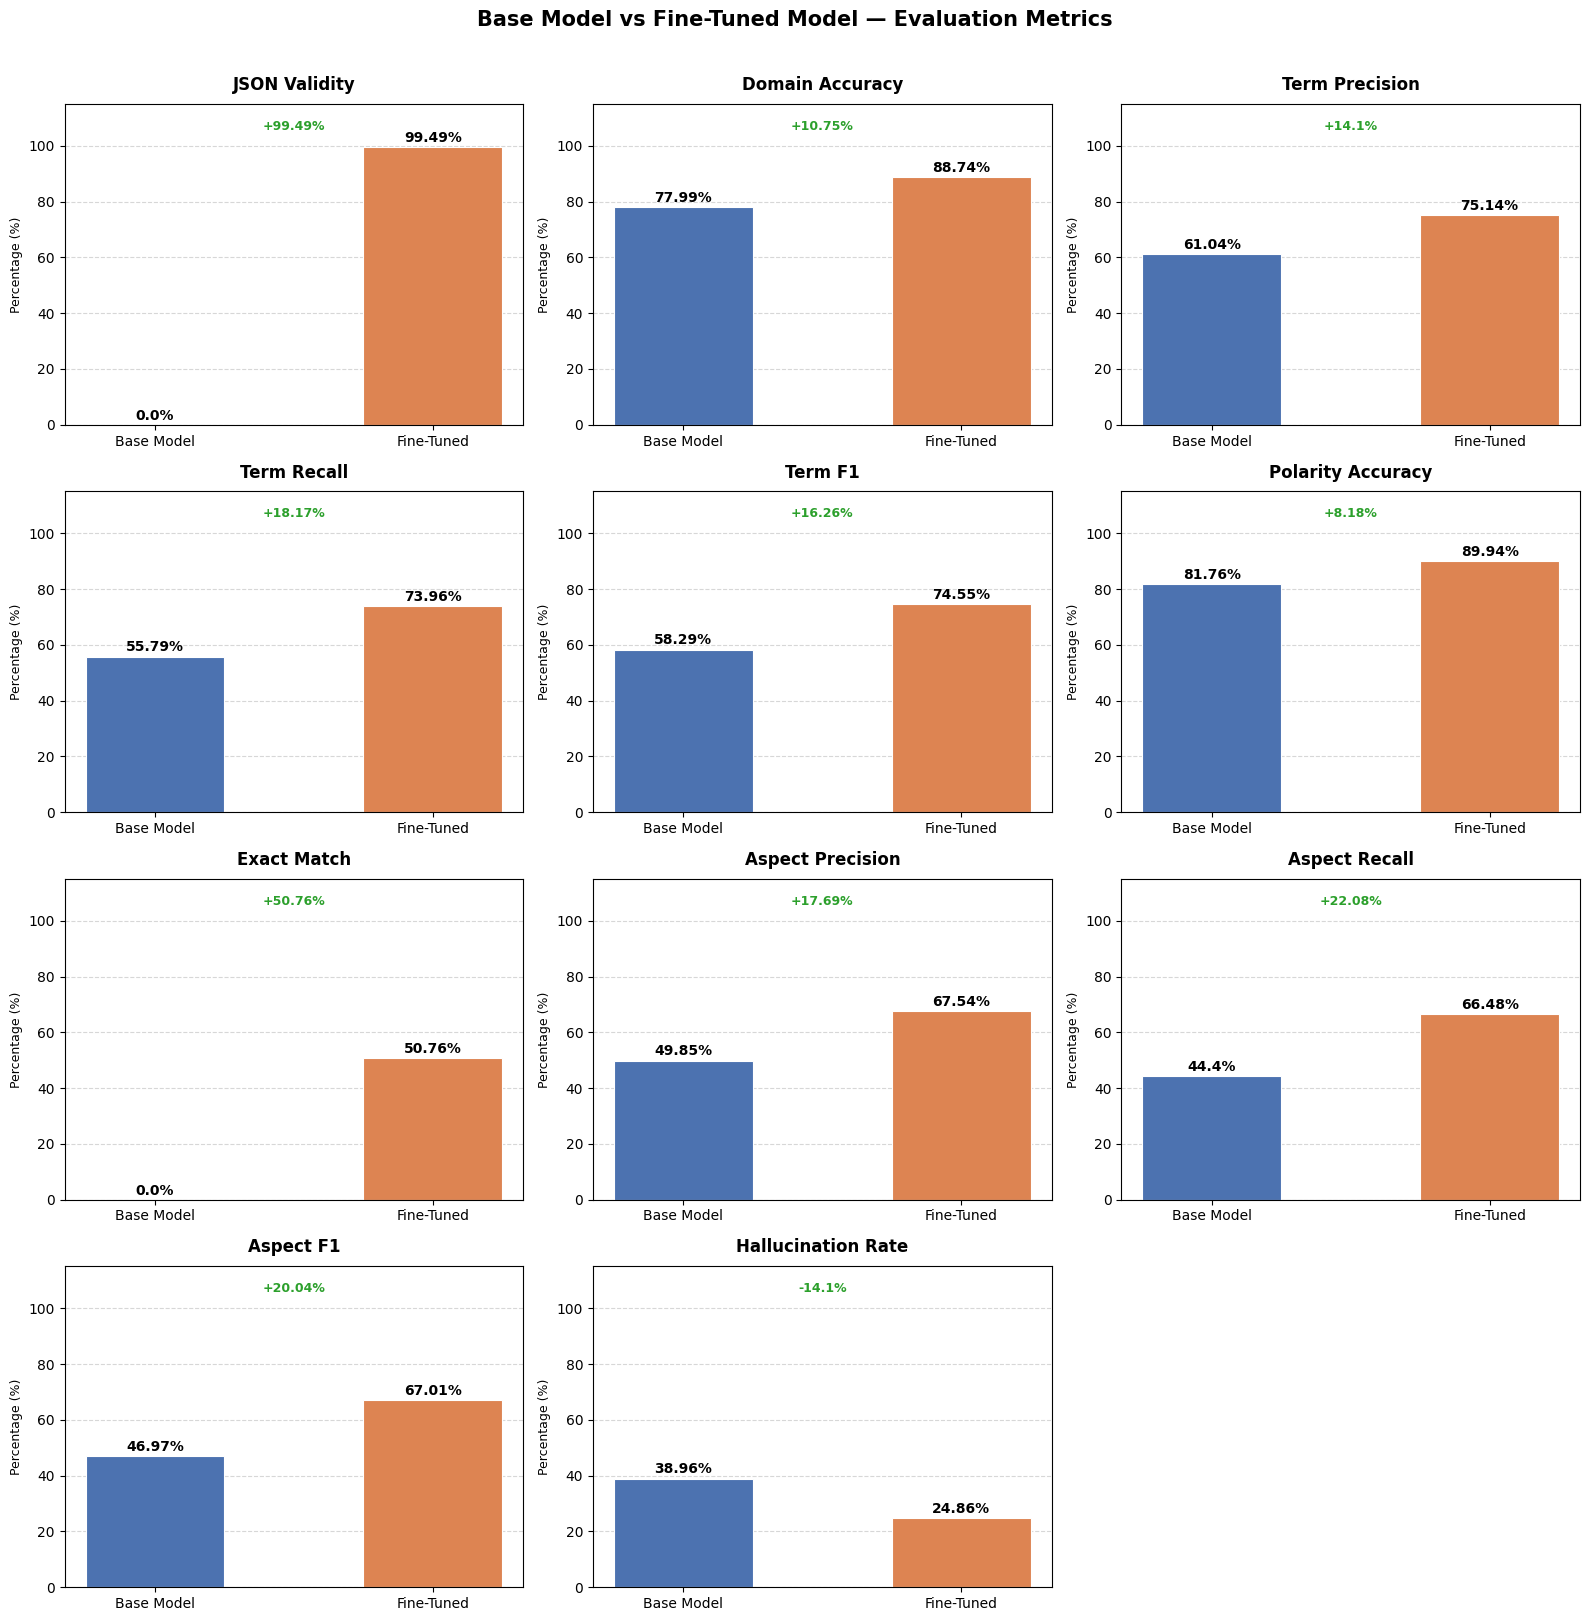

In [31]:

metrics = {
    "JSON Validity":        (base_json_accuracy,          finetuned_json_accuracy),
    "Domain Accuracy":      (base_domain_accuracy,         finetuned_domain_accuracy),
    "Term Precision":       (base_term_f1["precision"],    finetuned_term_f1["precision"]),
    "Term Recall":          (base_term_f1["recall"],       finetuned_term_f1["recall"]),
    "Term F1":              (base_term_f1["f1"],           finetuned_term_f1["f1"]),
    "Polarity Accuracy":    (base_polarity_accuracy,       finetuned_polarity_accuracy),
    "Exact Match":          (base_exact_match,             finetuned_exact_match),
    "Aspect Precision":     (base_aspect_f1["precision"],  finetuned_aspect_f1["precision"]),
    "Aspect Recall":        (base_aspect_f1["recall"],     finetuned_aspect_f1["recall"]),
    "Aspect F1":            (base_aspect_f1["f1"],         finetuned_aspect_f1["f1"]),
    "Hallucination Rate":   (base_hallucination,           finetuned_hallucination),
}

lower_is_better = {"Hallucination Rate"}

cols = 3
rows = math.ceil(len(metrics) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4))
axes = axes.flatten()

bar_width = 0.35
x = np.arange(2)
labels = ["Base Model", "Fine-Tuned"]
colors = ["#4C72B0", "#DD8452"]

for i, (metric_name, (base_val, ft_val)) in enumerate(metrics.items()):
    ax = axes[i]
    bars = ax.bar(x, [base_val, ft_val], color=colors, width=0.5, edgecolor="white", linewidth=0.8)

    for bar, val in zip(bars, [base_val, ft_val]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
                f"{val}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

    ax.set_title(metric_name, fontsize=12, fontweight="bold", pad=10)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_ylim(0, 115)
    ax.set_ylabel("Percentage (%)", fontsize=9)
    ax.yaxis.grid(True, linestyle="--", alpha=0.5)
    ax.set_axisbelow(True)

    diff = ft_val - base_val
    if metric_name in lower_is_better:
        improved = diff < 0
    else:
        improved = diff > 0

    if diff != 0:
        arrow_color = "#2ca02c" if improved else "#d62728"
        sign = "+" if diff > 0 else ""
        ax.annotate(f"{sign}{round(diff, 2)}%",
                    xy=(0.5, 0.92), xycoords="axes fraction",
                    ha="center", fontsize=9, color=arrow_color, fontweight="bold")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Base Model vs Fine-Tuned Model — Evaluation Metrics", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()